# Algoritmos de Gráficos por Computadora
### Bresenham · Círculo de Punto Medio · Rasterización Scanline
---

## 1. Preparar el entorno de dibujo

In [1]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

width, height = 200, 200
image = Image.new('RGB', (width, height), 'white')
pixels = image.load()

print(f'✅ Imagen creada: {width}x{height} píxeles, fondo blanco')

✅ Imagen creada: 200x200 píxeles, fondo blanco


## 2. Algoritmo de Bresenham (Línea)

El algoritmo de Bresenham permite trazar líneas en píxeles de forma eficiente usando solo aritmética entera. Calcula cuál píxel está más cerca de la línea ideal en cada paso.

Línea 1 dibujada: 161 píxeles
Línea 2 dibujada: 161 píxeles


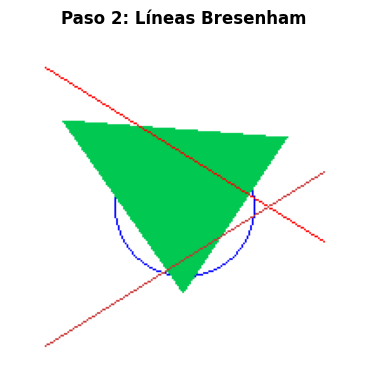

In [5]:
def bresenham(x0, y0, x1, y1, color=(255, 0, 0)):
    """Dibuja una línea usando el algoritmo de Bresenham."""
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx - dy

    puntos = 0
    while True:
        if 0 <= x0 < width and 0 <= y0 < height:
            pixels[x0, y0] = color
            puntos += 1
        if x0 == x1 and y0 == y1:
            break
        e2 = 2 * err
        if e2 > -dy:
            err -= dy
            x0 += sx
        if e2 < dx:
            err += dx
            y0 += sy
    return puntos

# Probar con distintas líneas
n1 = bresenham(20, 20, 180, 120)           # Línea roja principal
n2 = bresenham(20, 180, 180, 80, (200, 50, 50))  # Línea roja secundaria

print(f'Línea 1 dibujada: {n1} píxeles')
print(f'Línea 2 dibujada: {n2} píxeles')

# Mostrar resultado parcial
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(image)
ax.set_title('Paso 2: Líneas Bresenham', fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Algoritmo de Círculo de Punto Medio

Basado en la simetría de 8 octantes del círculo, este algoritmo traza el círculo completo calculando solo 1/8 de los puntos y reflejándolos.

Círculo externo: 232 píxeles
Círculo interno: 88 píxeles


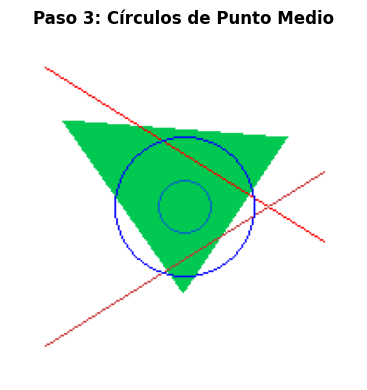

In [6]:
def midpoint_circle(x0, y0, radius, color=(0, 0, 255)):
    """Dibuja un círculo usando el algoritmo de punto medio."""
    x = radius
    y = 0
    p = 1 - radius
    puntos = 0

    while x >= y:
        for dx, dy in [(x,y),(y,x),(-x,y),(-y,x),(-x,-y),(-y,-x),(x,-y),(y,-x)]:
            px, py = x0 + dx, y0 + dy
            if 0 <= px < width and 0 <= py < height:
                pixels[px, py] = color
                puntos += 1
        y += 1
        if p <= 0:
            p = p + 2*y + 1
        else:
            x -= 1
            p = p + 2*y - 2*x + 1
    return puntos

# Círculo principal
n3 = midpoint_circle(100, 100, 40)
# Círculo pequeño decorativo
n4 = midpoint_circle(100, 100, 15, (0, 100, 200))

print(f'Círculo externo: {n3} píxeles')
print(f'Círculo interno: {n4} píxeles')

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(image)
ax.set_title('Paso 3: Círculos de Punto Medio', fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Relleno de Triángulo (Scanline)

La rasterización por scanline recorre cada línea horizontal dentro del triángulo e interpola los bordes para determinar qué píxeles rellenar.

Triángulo relleno: 6165 píxeles


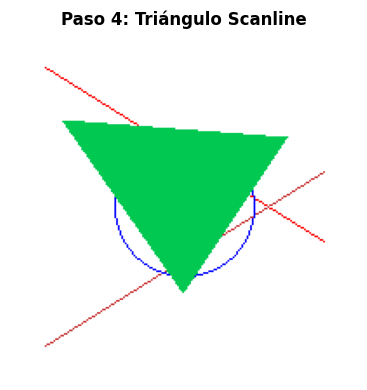

In [7]:
def fill_triangle(p1, p2, p3, color=(0, 200, 80)):
    """Rellena un triángulo usando rasterización scanline."""
    # Ordenar vértices por coordenada Y
    pts = sorted([p1, p2, p3], key=lambda p: p[1])
    (x1, y1), (x2, y2), (x3, y3) = pts

    def interpolate(ya, yb, xa, xb):
        """Interpolación lineal de X para cada fila Y entre ya e yb."""
        if yb - ya == 0:
            return []
        return [int(xa + (xb - xa) * (y - ya) / (yb - ya)) for y in range(ya, yb)]

    x12 = interpolate(y1, y2, x1, x2)   # Borde inferior izquierdo
    x23 = interpolate(y2, y3, x2, x3)   # Borde inferior derecho
    x13 = interpolate(y1, y3, x1, x3)   # Borde completo

    x_left = x12 + x23
    pixeles = 0
    for y, xl, xr in zip(range(y1, y3), x13, x_left):
        for x in range(min(xl, xr), max(xl, xr)):
            if 0 <= x < width and 0 <= y < height:
                pixels[x, y] = color
                pixeles += 1
    return pixeles

n5 = fill_triangle((30, 50), (100, 150), (160, 60))
print(f'Triángulo relleno: {n5} píxeles')

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(image)
ax.set_title('Paso 4: Triángulo Scanline', fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Resultado Final Combinado

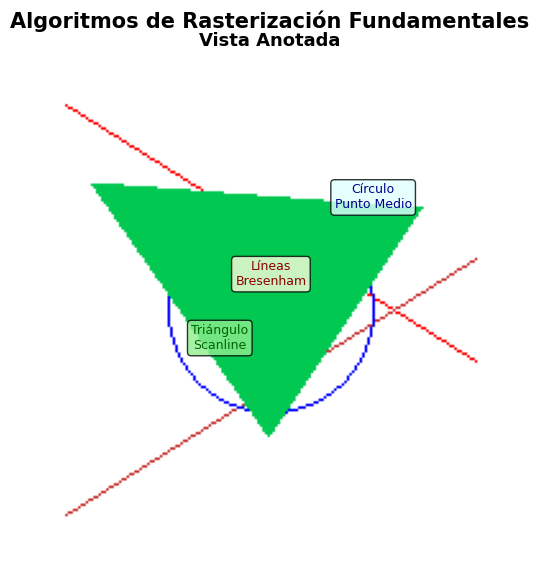

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))

# Versión ampliada con anotaciones
ax.imshow(image)
ax.annotate('Líneas\nBresenham', xy=(100, 90), fontsize=9,
                 color='darkred', ha='center',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
ax.annotate('Círculo\nPunto Medio', xy=(140, 60), fontsize=9,
                 color='darkblue', ha='center',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcyan', alpha=0.8))
ax.annotate('Triángulo\nScanline', xy=(80, 115), fontsize=9,
                 color='darkgreen', ha='center',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.8))
ax.set_title('Vista Anotada', fontsize=13, fontweight='bold')
ax.axis('off')

plt.suptitle('Algoritmos de Rasterización Fundamentales', fontsize=15, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()

---
##  Resumen de Algoritmos

| Algoritmo | Color | Complejidad | Ventaja |
|-----------|-------|-------------|----------|
| **Bresenham (línea)** | 🔴 Rojo | O(max(Δx,Δy)) | Solo aritmética entera |
| **Punto Medio (círculo)** | 🔵 Azul | O(r) | Simetría de 8 octantes |
| **Scanline (triángulo)** | 🟢 Verde | O(n²) | Relleno completo |

### ¿Cómo funciona cada uno?
- **Bresenham**: Usa el error acumulado para decidir si avanzar en X, Y o ambos
- **Punto Medio**: Calcula 1/8 del círculo y lo refleja 8 veces
- **Scanline**: Interpola los bordes y rellena cada fila horizontal
